In [1]:
import time
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l
 

In [2]:
def add_to_class(Class):
    def wrapper(obj):
        setattr(Class, obj.__name__, obj)
    return wrapper

In [3]:
class A:
    def __init__(self):
        self.b = 1
a = A()

@add_to_class(A)
def do(self):
    print(f"value of b : {self.b}")

a.do()


value of b : 1


In [4]:
class B(d2l.HyperParameters):
    def __init__(self, a, b, c):
        self.save_hyperparameters(ignore=['c'])
        print(f"a : {self.a} b : {self.b}")
b = B(1, 2, 3)

a : 1 b : 2


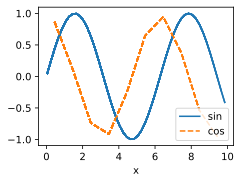

In [5]:
#Not actual implementation
class ProgressBoard(d2l.HyperParameters):
    def __init__(self, xlabel=None, ylable=None, xscale="linear", yscale="linear",
                 xlim=None, ylim=None, ls=['-', '--', '-.', ':'], colors=['C0', 'C1', 'C2', 'C3'], figsize=(3.5, 2.5), display=True):
        self.save_hyperparameters()
    def draw(self, x, y, label, every_n=1):
        pass

board = d2l.ProgressBoard('x')
for x in np.arange(0, 10, 0.1):
    board.draw(x, np.sin(x), 'sin', every_n=2)
    board.draw(x, np.cos(x), 'cos', every_n=10)


In [6]:
class Module(nn.Module, d2l.HyperParameters): #@save
    def __init__(self, plot_train_per_epoch=2, plot_valid_per_epoch=1):
        super().__init__()
        self.save_hyperparameters()
        self.board = ProgressBoard()

    def loss(self, y_hat, y):
        raise NotImplementedError
    
    def forward(self, X):
        assert hasattr(self, 'net')
        return self.net(X)
    
    def plot(self, key, value, train):
        assert hasattr(self, "trainer")
        self.board.xlabel = "epoch"
        if train:
            x = self.trainer.train_batch_idx / self.trainer.num_train_batches
            n = self.trainer.num_train_batches / self.plot_train_per_epoch
        else:
            x = self.trainer.epoch + 1
            n = self.trainer.num_val_batches / self.plot_valid_per_epoch
        self.board.draw(x, value.detach().cpu(), key, every_n=int(n))
    
    def training_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=True)
        return l

    def validation_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=False)

    def configure_optimizers(self):
         raise NotImplementedError


In [7]:
class DataModule(d2l.HyperParameters): #@save
    def __init__(self, root="../data", num_workers=4):
        self.save_hyperparameters()
    def get_dataloader(self, train):
        raise NotImplementedError
    def train_dataloader(self):
        return self.get_dataloader(train=True)
    def val_dataloader(self):
        return self.get_dataloader(train=False)

In [8]:
class Trainer(d2l.HyperParameters): #@save
    def __init__(self, max_epochs, num_gpu=0, gradient_clip_val=0):
        self.save_hyperparameters()
        assert num_gpu == 0, 'No GPU support yet'
    
    def prepare_data(self, data):
        self.train_dataloader = data.train_dataloader()
        self.val_dataloader = data.val_dataloader()
        self.num_train_batches = len(self.train_dataloader)
        self.num_val_batches = (len(self.val_dataloader)) if self.val_dataloader is not None else 0
    
    def prepare_model(self, model):
        model.trainer = self
        model.board.xlim = [0, self.max_epochs]
        self.model = model
    
    def fit(self, model, data):
        self.prepare_data(data)
        self.prepare_model(model)
        self.optim = model.configure_optimizers()
        self.epoch = 0
        self.train_batch_idx = 0
        self.val_batch_idx = 0
        for self.epoch in range(self.max_epochs):
            self.fit_epoch()
        
    def fit_epoch(self):
        raise NotImplementedError
            

    

In [9]:
import inspect

def print_agrs():
    frame = inspect.currentframe().f_back
    print(f"args : {inspect.getargvalues(frame)}")

def sample_method(a,b,c):
    print_agrs()

sample_method(1,2,3)    


args : ArgInfo(args=['a', 'b', 'c'], varargs=None, keywords=None, locals={'a': 1, 'b': 2, 'c': 3})


In [10]:
class SyntheticRegressionData(d2l.DataModule): #@save
    def __init__(self, w, b, noise=0.01, num_train=1024, num_val=1024, batch_size=32):
        super().__init__()
        self.save_hyperparameters()
        n = num_train + num_val
        self.X = torch.randn((n, len(w)))
        noise = torch.randn(n, 1) * noise
        self.y = torch.matmul(self.X, w.reshape(-1, 1)) + b + noise


In [11]:
data = SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
print('features:', data.X.shape, '\nlabels:', data.y.shape)
print(data.X[:2], '\n', data.y[:2])

features: torch.Size([2048, 2]) 
labels: torch.Size([2048, 1])
tensor([[-0.1488,  0.1289],
        [ 0.8729,  0.5131]]) 
 tensor([[3.4366],
        [4.1993]])


In [12]:
import random

@d2l.add_to_class(SyntheticRegressionData)
def get_dataloader(self, train):
    if train:
        indices = list(range(0, self.num_train))
        random.shuffle(indices)
    else:
        indices = list(range(self.num_train, self.num_train + self.num_val))
    for i in range(0, len(indices), self.batch_size):
        batch_indices = torch.tensor(indices[i:min(i + self.batch_size, len(indices))])
        yield self.X[batch_indices], self.y[batch_indices]

X, y = next(iter(data.train_dataloader()))
print('X shape:', X.shape, '\ny shape:', y.shape)

X shape: torch.Size([32, 2]) 
y shape: torch.Size([32, 1])


In [13]:
@d2l.add_to_class(d2l.DataModule) #@save
def get_tensorloader(self, tensors, train, indices=slice(0, None)):
    tensors = tuple(a[indices] for a in tensors)
    dataset = torch.utils.data.TensorDataset(*tensors)
    return torch.utils.data.DataLoader(dataset, self.batch_size,shuffle=train)

@d2l.add_to_class(SyntheticRegressionData) #@save
def get_dataloader(self, train):
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader((self.X, self.y), train, i)

X, y = next(iter(data.train_dataloader()))
print('X shape:', X.shape, '\ny shape:', y.shape)

X shape: torch.Size([32, 2]) 
y shape: torch.Size([32, 1])


In [14]:
# A simple sample generator function
def fn(max=10):
    cnt=0
    while cnt<max:
        yield cnt
        cnt+=1
        print("Incremented cnt")

gn = fn(5)
next(gn)
next(gn)

Incremented cnt


1

In [15]:
@d2l.add_to_class(SyntheticRegressionData)
def data_generator(self):
    while True:
        X = torch.randn(self.batch_size, self.w.size()[0])
        y = torch.matmul(X, self.w.reshape(-1, 1)) + self.b + self.noise * torch.randn(self.batch_size, 1)
        yield X, y

In [16]:
data_gn = data.data_generator()
print(f"X size : {next(data_gn)[0].size()}")
print(f"X[0] : {next(data_gn)[0][0]}")
print(f"X[0] : {next(data_gn)[0][0]}")
print(f"X[0] : {next(data_gn)[0][0]}")

X size : torch.Size([32, 2])
X[0] : tensor([-1.0296, -1.8189])
X[0] : tensor([0.5627, 1.1429])
X[0] : tensor([-1.3494,  0.4818])


In [17]:
#Sample gradient for a tensor
x = torch.arange(0, 4, dtype=torch.float32, requires_grad=True)

y = x * x
y.backward(gradient=torch.ones(len(y)))
x.grad

tensor([0., 2., 4., 6.])

In [18]:
#Linear regression from scratch

class LinearRegressionFromScratch(d2l.Module): #@save
    def __init__(self, num_inputs:int, lr:float, sigma=0.01, loss_type="MSE"):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.normal(mean=0, std=sigma, size=(num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

    def forward(self, X:torch.Tensor):
        return torch.matmul(X, self.w) + self.b
    
    def loss(self, y_hat:torch.Tensor, y:torch.Tensor):
        if self.loss_type == "MSE":
            l = (y - y_hat) ** 2 / 2
        else:
            l = (y-y_hat).abs()
        return l.mean()


In [19]:
class SGD(d2l.HyperParameters):
    def __init__(self, params:torch.Tensor, lr:float):
        self.save_hyperparameters()

    def step(self):
        for param in self.params:
            param -= self.lr*param.grad
    
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()
    


In [20]:
@d2l.add_to_class(LinearRegressionFromScratch)
def configure_optimizers(self):
    return SGD([self.w, self.b], self.lr)

@d2l.add_to_class(d2l.Trainer)
def prepare_batch(self, batch):
    return batch

@d2l.add_to_class(d2l.Trainer)
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            if self.gradient_clip_val > 0:
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()
        self.train_batch_idx += 1
        if self.val_dataloader is None:
            return
        self.model.eval()
        for batch in self.val_dataloader:
            with torch.no_grad():
                self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

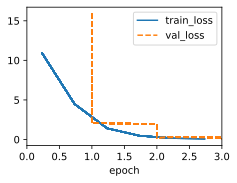

In [21]:
model = LinearRegressionFromScratch(2, lr=0.03, sigma=0.01)
data = SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

In [22]:
with torch.no_grad():
    print(f"error in estimating w: {data.w - model.w.reshape(-1)}")
    print(f"error in estimating b: {data.b - model.b}")

error in estimating w: tensor([ 0.0543, -0.1474])
error in estimating b: tensor([0.1927])


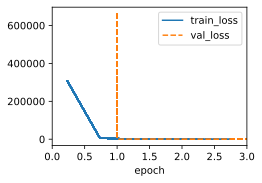

In [23]:
model = LinearRegressionFromScratch(2, lr=0.1, sigma=1000)
data = SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

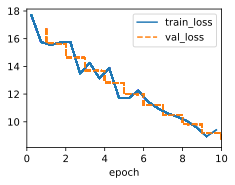

In [24]:
model = LinearRegressionFromScratch(2, lr=0.001, sigma=0.01)
data = SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

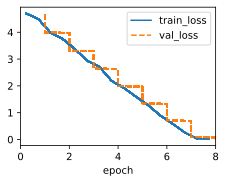

In [25]:
model = LinearRegressionFromScratch(2, lr=0.03, sigma=0.01, loss_type="MAE")
data = SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=8)
trainer.fit(model, data)

In [26]:
with torch.no_grad():
    print(f"error in estimating w: {data.w - model.w.reshape(-1)}")
    print(f"error in estimating b: {data.b - model.b}")

error in estimating w: tensor([-0.0074, -0.0042])
error in estimating b: tensor([-0.0019])


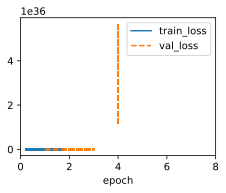

In [27]:
model = LinearRegressionFromScratch(2, lr=0.1, sigma=0.01)
data = SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
data.X[0] = data.X[0] * 1000
data.y[0] = data.y[0] * 1000
data.X[1] = data.X[1] * 1200
data.y[1] = data.y[1] * 1200

trainer = d2l.Trainer(max_epochs=8)
trainer.fit(model, data)

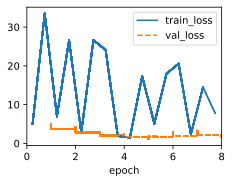

In [28]:
model = LinearRegressionFromScratch(2, lr=0.03, sigma=0.01, loss_type="MAE")
data = SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
data.X[0] = data.X[0] * 1000
data.y[0] = data.y[0] * 1000
data.X[1] = data.X[1] * 1200
data.y[1] = data.y[1] * 1200

trainer = d2l.Trainer(max_epochs=8)
trainer.fit(model, data)

In [29]:
import numpy as numpy
import torch
from torch import nn
from d2l import torch as d2l


In [30]:
#Implementing linear regression using high level APIs

class LinearRegression(d2l.Module):
    def __init__(self, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.LazyLinear(1)
        self.net.weight.data.normal_(0, 0.01)
        self.net.bias.data.fill_(0)

    def forward(self, X):
        return self.net(X)
    
    def loss(self, y, y_hat):
        fn = nn.MSELoss()
        return fn(y_hat, y)
    
    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(), lr=self.lr)

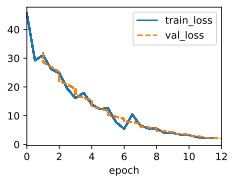

In [31]:
model = LinearRegression(lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2, num_train=64, num_val=1024)
trainer = d2l.Trainer(max_epochs=12)
trainer.fit(model, data)

In [32]:
@d2l.add_to_class(LinearRegression)
def get_w_b(self):
    return (self.net.weight.data, self.net.bias.data)

w, b = model.get_w_b()
with torch.no_grad():
    print(f"error in estimating w: {data.w - w.reshape(data.w.shape)}")
    print(f"error in estimating b: {data.b - b}")

error in estimating w: tensor([ 0.6836, -0.3975])
error in estimating b: tensor([1.1030])


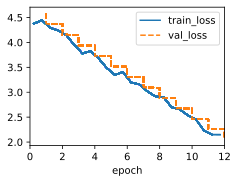

In [33]:
#Linear regression with Huber loss
class LinearRegression(d2l.Module):
    def __init__(self, lr=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.LazyLinear(1)
        
    def forward(self, X):
        return self.net(X)
    
    def loss(self, y, y_hat):
        fn = nn.HuberLoss(delta=1)
        return fn(y_hat, y)
    
    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(), lr=self.lr)
    

model = LinearRegression(lr=0.01)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=12)
trainer.fit(model, data)

In [34]:
#Accessing gradients of weights in a model
for name, param in model.named_parameters():
    print(f"Layer: {name} Value: {param.grad}")


Layer: net.weight Value: tensor([[0.0402, 0.6692]])
Layer: net.bias Value: tensor([-0.6868])


In [35]:
class Data(d2l.DataModule):
    def __init__(self, num_train, num_val, num_inputs,batch_size):
        self.save_hyperparameters()
        n = num_train + num_val
        self.X = torch.randn((n, num_inputs))
        noise = torch.randn(n, 1) * 0.01
        w, b = torch.ones(num_inputs, 1) * 0.01, 0.05
        self.y = torch.matmul(self.X, w) + b + noise

    def get_dataloader(self, train):
        i = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader((self.X, self.y), train, i)


In [36]:
class WeightDecayScratch(d2l.LinearRegressionScratch):
    def __init__(self, num_inputs, lr, lambd,sigma=0.01):
        super().__init__(num_inputs, lr, sigma)
        self.save_hyperparameters()
        self.lambd = lambd

    def l2_penalty(self):
        return torch.sum(self.w**2) / 2

    def loss(self, y_hat, y):
        return super().loss(y_hat, y) + self.lambd * self.l2_penalty()

    


In [37]:
data = Data(num_train=20, num_val=100, num_inputs=200, batch_size=5)
trainer = d2l.Trainer(max_epochs=10)

def train_scratch(lambd):
    model = WeightDecayScratch(num_inputs=200, lr=0.01, lambd=lambd)
    model.board.yscale = 'log'    
    trainer.fit(model, data)
    print(f'L2 norm of w {float(model.l2_penalty()):f}')

L2 norm of w 0.009281


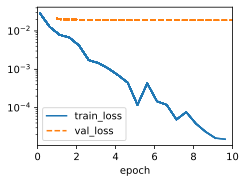

In [38]:
train_scratch(0)

L2 norm of w 0.000643


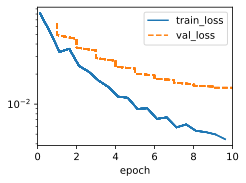

In [39]:
train_scratch(5)

In [40]:
class WeightDecay(d2l.LinearRegression):
    def __init__(self, wd, lr):
        super().__init__(lr)
        self.save_hyperparameters()
        self.wd = wd
    def configure_optimizers(self):
        return torch.optim.SGD(params=[
            {
                'params':self.net.weight,
                'weight_decay':self.wd
            },
            {
                'params':self.net.bias
            }
        ], lr=self.lr)


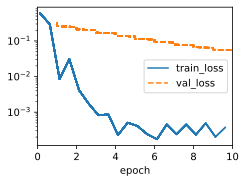

In [41]:
model = WeightDecay(wd=3, lr=0.01)
model.board.yscale='log'
trainer.fit(model, data)

In [68]:
class LinearRegression(d2l.Module):
    def __init__(self, weight_decay, lr=0.01, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.linear_layer = nn.LazyLinear(1)
        self.linear_layer.weight.data.normal_(0, sigma)
        self.linear_layer.bias.data.fill_(0)
        self.weight_decay = weight_decay
        self.training_loss_per_epoch = []
        self.validation_loss_per_epoch = []

    def forward(self, X):
        return self.linear_layer(X)
    
    def loss(self, y_hat, y):
        loss_fn = nn.MSELoss()
        return loss_fn(y_hat, y)
    
    def training_step(self, batch):
        loss = self.loss(self(*batch[:-1]), batch[-1])
        self.training_loss_per_epoch.append(loss.detach().numpy())
        return loss
    
    def validation_step(self, batch):
        loss = self.loss(self(*batch[:-1]), batch[-1])
        self.validation_loss_per_epoch.append(loss.detach().numpy())
        return loss
    
    def configure_optimizers(self):
        return torch.optim.SGD([
            {
                'params':self.linear_layer.weight,
                'weight_decay':self.weight_decay
            },
            {
                'params':self.linear_layer.bias
            }
        ], lr=self.lr)    


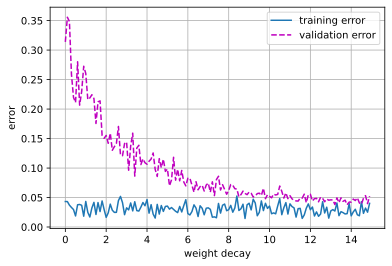

In [74]:
data = Data(num_train=20, num_val=100, num_inputs=200, batch_size=5)

weight_decays = torch.arange(0, 15, 0.1)
training_error = []
validation_error = []

for wd in weight_decays:
    model = LinearRegression(wd, lr=0.01, sigma=0.01)
    trainer = d2l.Trainer(max_epochs=10)
    trainer.fit(model, data)
    training_error.append(sum(model.training_loss_per_epoch) / len(model.training_loss_per_epoch))
    validation_error.append(sum(model.validation_loss_per_epoch) / len(model.validation_loss_per_epoch))

d2l.plot(X=weight_decays.detach().numpy(), Y=[training_error, validation_error], 
         xlabel='weight decay', ylabel='error', legend=['training error', 'validation error'], figsize=(6, 4))


In [ ]:
#https://bjlkeng.io/posts/probabilistic-interpretation-of-regularization/